# 02 — Decision Engine

**Goal**: Keep analysis clear and business-credible while adding pragmatic guardrails.

### What this notebook does
- Loads the SaaS snapshot and aggregates KPIs at Region x Segment.
- Runs what-if scenarios with a simple policy model.
- Provides a **guarded greedy** plan under budget with realistic constraints:
  - per-cell uplift caps (avoid stacking unrealistic growth)
  - diminishing returns when repeating the same lever on the same cell
  - max steps per cell/lever
  - payback gate (reject moves with payback beyond a target months)
  - **minimum net impact guardrail** (reject moves with negligible business impact)
- Outputs a compact comparison table and an optional heatmap suitable for slides.
- All comments are in English; visuals are minimal by design.

### How to Use
**Prerequisites**
```
ai-decision-intelligence-main/
├── data/processed/saas_financial_snapshot.csv
├── src/decision_engine/
│   ├── kpis.py              # compute_cfo_kpis
│   ├── policies.py          # apply_policy (pure, caps/decay handled there)
│   └── prioritization.py    # (optional) your helpers — not strictly required here
└── notebooks/02_decision_engine_v2_1_optimized.ipynb (this file)
```

**Execution**
1. Run cells top to bottom
2. Adjust guardrails (BUDGET, CAPS, DECAY, MIN_DELTA_NET, MAX_ITER) if needed
3. Results exported to `../outputs/decision_engine_outputs/`

**Deliverables**
- Baseline KPIs (GRR, NRR, Net ARR)
- Scenario comparisons (3 strategies)
- Greedy ROI-optimized plan under budget with guardrails
- Heatmap (Region x Segment) and exported CSV/JSON


## 01 — Imports & Config

In [1]:
import sys
import json
from pathlib import Path
from collections import defaultdict
import importlib

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Project root & src path (works if notebook lives in notebooks/)
notebook_dir = Path.cwd() if Path.cwd().name == 'notebooks' else Path.cwd() / 'notebooks'
project_root = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir
src_path = project_root / 'src' / 'decision_engine'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Local modules
try:
    from kpis import compute_cfo_kpis
    import policies
    importlib.reload(policies)
    from policies import apply_policy
except Exception as e:
    raise ImportError(
        f'❌ Failed to import local modules: {e}\n'
        f'Ensure src/decision_engine/ contains kpis.py and policies.py'
    )

# Plot configs
mpl.rcParams['font.family'] = 'DejaVu Sans'  # avoid glyph warnings
sns.set_theme(style='whitegrid')
plt.rcParams.update({'axes.titlesize':12,'axes.labelsize':10,'legend.fontsize':9,'figure.figsize':(9,4.8)})

# Format helpers
fmt_eur = lambda x: f"{x:,.0f} EUR".replace(',', ' ')
fmt_pct = lambda x: f"{x*100:,.1f}%".replace(',', ' ')


## 02 — Load & Aggregate (Region × Segment)

In [2]:
data_path = project_root / 'data' / 'processed' / 'saas_financial_snapshot.csv'
if not data_path.exists():
    raise FileNotFoundError(
        f'❌ Data file not found: {data_path}\n'
        f'Expected: project_root/data/processed/saas_financial_snapshot.csv'
    )

df = pd.read_csv(data_path)

# Required schema
required_cols = [
    'annual_contract_value','opening_arr','new_arr','churned_arr',
    'reactivated_arr','expansion_arr','contraction_arr','net_arr_change'
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'❌ Missing required columns in CSV: {missing_cols}')

for col in required_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0)

df['segment'] = df['segment'].fillna('SMB')
df['region']  = df['region'].fillna('Other')

kpi_by_region_segment = df.groupby(['region','segment']).agg(
    opening=('opening_arr','sum'),
    arr=('annual_contract_value','sum'),
    churned=('churned_arr','sum'),
    new=('new_arr','sum'),
    reactivated=('reactivated_arr','sum'),
    expansion=('expansion_arr','sum'),
    contraction=('contraction_arr','sum'),
    accounts=('account_id','nunique')
).reset_index()

print(f'✓ Loaded {len(df):,} rows → aggregated to {len(kpi_by_region_segment)} cells')
kpi_by_region_segment.head()


✓ Loaded 500 rows → aggregated to 9 cells


,region,segment,opening,arr,churned,new,reactivated,expansion,contraction,accounts
0,APAC,Corporate,391344.0,1043748,51744.0,426456.0,209028.0,0,0,28
1,APAC,Enterprise,203328.0,841788,95772.0,549204.0,178452.0,0,0,21
2,APAC,SMB,311556.0,924684,11940.0,602664.0,119004.0,0,0,32
3,EMEA,Corporate,286956.0,993468,39060.0,477252.0,166500.0,0,0,31
4,EMEA,Enterprise,231108.0,1506108,125148.0,502704.0,253476.0,0,0,39


## 03 — Baseline CFO KPIs (Opening‑based)

In [3]:
# Baseline at global level
base_global = compute_cfo_kpis(kpi_by_region_segment.sum(numeric_only=True).to_frame().T)
base_global


,opening,arr,churned,new,reactivated,expansion,contraction,accounts,net,gross_churn,GRR,NRR,net_growth_pct
0,4891680.0,14834016.0,1439928.0,9281448.0,3777048.0,0.0,0.0,500.0,11618568.0,0.294363,0.705637,0.705637,2.375169


## 04 — Guardrails & Effort Model (adjustable)

Deliberately simple; tune as needed. (You can move constants to `src/` later.)

In [4]:
# Effort coefficients (abstract units)
DEFAULT_EFFORT = {
    'a_churn': 1.0,
    'a_new':   0.6,
    'a_react': 0.4,
    'a_exp':   0.7,
    'a_cont':  0.8,
}

# Caps & decay
MAX_NEW_UPLIFT   = 0.20    # +20% cap per cell
MAX_REACT_UPLIFT = 0.30    # +30% cap per cell
CAPS  = {'max_new_uplift': MAX_NEW_UPLIFT, 'max_react_uplift': MAX_REACT_UPLIFT}
DECAY = 0.85               # diminishing returns factor per repeated move
MAX_STEPS_PER_CELL_LEVER = 5

# Effort -> EUR mapping for payback gate
EFFORT_UNIT_TO_EUR = 10_000.0  # 1 unit = 10k EUR all-in cost (Sales+Mktg+CS blended)
GROSS_MARGIN    = 0.80
MAX_PAYBACK_MONTHS = 18

# NEW: minimum business-impact guardrail
MIN_DELTA_NET   = 1_000.0   # reject moves with <1k EUR net ARR impact

# Elementary steps per lever (kept realistic)
STEPS = {
    'churn_bps': 50,     # reduce churn by 50 bps per step
    'new_pct':   0.02,   # +2% new logo ARR per step
    'react_pct': 0.05,   # +5% reactivation ARR per step
}

# Safety: max greedy iterations
MAX_ITER = 500


## 05 — Scenario Runner (pure what‑if, baseline passed once)

In [5]:
def run_scenario(kpi_df: pd.DataFrame, policy: dict, name: str,
                 baseline_g: pd.DataFrame,
                 effort_coeffs=None, caps=None):
    """Apply a single policy, return simulated KPIs vs provided baseline."""
    if effort_coeffs is None:
        effort_coeffs = DEFAULT_EFFORT
    if caps is None:
        caps = CAPS

    kpi_sim, effort_units = apply_policy(kpi_df, policy, effort_coeffs=effort_coeffs, caps=caps)
    sim_g  = compute_cfo_kpis(kpi_sim.sum(numeric_only=True).to_frame().T)
    delta_g = pd.DataFrame({
        'Scenario':      [name],
        'Delta Net ARR (EUR)': sim_g['net'].iat[0] - baseline_g['net'].iat[0],
        'Delta GRR (pct)': (sim_g['GRR'].iat[0] - baseline_g['GRR'].iat[0]) * 100,
        'Delta NRR (pct)': (sim_g['NRR'].iat[0] - baseline_g['NRR'].iat[0]) * 100,
        'Effort (units)':   effort_units,
    })
    return kpi_sim, delta_g

def compare_scenarios(kpi_df: pd.DataFrame, scenarios: dict,
                      baseline_g: pd.DataFrame,
                      effort_coeffs=None, caps=None) -> pd.DataFrame:
    """Run multiple scenarios — baseline passed once to avoid re-compute noise."""
    rows = []
    for name, pol in scenarios.items():
        _, d = run_scenario(kpi_df, pol, name, baseline_g,
                            effort_coeffs=effort_coeffs, caps=caps)
        rows.append(d.iloc[0])
    out = pd.DataFrame(rows)
    return out[['Scenario','Delta Net ARR (EUR)','Delta GRR (pct)','Delta NRR (pct)','Effort (units)']]


## 06 — Greedy Engine (no globals; payback + min impact; iteration safety)

1. Payback Gate

In [6]:
def payback_ok(delta_net_eur: float, effort_units: float) -> bool:
    """Payback(months) = Cost / (Gross Profit / 12) ≤ MAX_PAYBACK_MONTHS, and Delta Net >= MIN_DELTA_NET."""
    if delta_net_eur < MIN_DELTA_NET:
        return False
    gp = max(0.0, delta_net_eur * GROSS_MARGIN)
    cost = effort_units * EFFORT_UNIT_TO_EUR
    if gp <= 0:
        return False
    payback_mo = cost / (gp / 12.0)
    return payback_mo <= MAX_PAYBACK_MONTHS

2. ROI Maximizer (Best Move Finder)

In [7]:
def best_move_given_state(kpi_sim: pd.DataFrame,
                          applied_counts: dict,
                          effort_coeffs=None, caps=None, steps: dict = None):
    """Evaluate all candidate moves; return best ROI dict or None."""
    if effort_coeffs is None:
        effort_coeffs = DEFAULT_EFFORT
    if caps is None:
        caps = CAPS
    if steps is None:
        steps = STEPS

    base_g = compute_cfo_kpis(kpi_sim.sum(numeric_only=True).to_frame().T)
    base_net = base_g['net'].iat[0]

    candidates = []
    for _, row in kpi_sim.iterrows():
        reg, seg = row['region'], row['segment']
        for lever, step in steps.items():
            n_used = applied_counts.get((reg, seg, lever), 0)
            if n_used >= MAX_STEPS_PER_CELL_LEVER:
                continue
            effective_step = step * (DECAY ** n_used)
            if effective_step <= 0:
                continue

            pol = {'cell': {(reg, seg): {lever: effective_step}}}
            after, effort = apply_policy(kpi_sim, pol, effort_coeffs=effort_coeffs, caps=caps)
            after_g = compute_cfo_kpis(after.sum(numeric_only=True).to_frame().T)
            dnet = after_g['net'].iat[0] - base_net

            if not payback_ok(dnet, effort):
                continue
            roi = dnet / max(effort, 1e-6)
            candidates.append({
                'region': reg,
                'segment': seg,
                'lever': lever,
                'step': effective_step,
                'delta_net': dnet,
                'effort': effort,
                'ROI': roi,
            })

    if not candidates:
        return None
    cand_df = pd.DataFrame(candidates).sort_values('ROI', ascending=False)
    return cand_df.iloc[0].to_dict()


3. Greedy Allocator (Budget-Constrained Loop)

In [8]:

def greedy_allocate(kpi_df: pd.DataFrame, budget: float,
                    effort_coeffs=None, caps=None, steps: dict = None,
                    max_iter: int = MAX_ITER):
    """Budget-constrained greedy with caps, decay, max steps, payback, min impact, and iteration limit."""
    if effort_coeffs is None:
        effort_coeffs = DEFAULT_EFFORT
    if caps is None:
        caps = CAPS
    if steps is None:
        steps = STEPS

    applied_counts = defaultdict(int)  # local, no global state
    kpi_sim = kpi_df.copy()
    spent = 0.0
    picks = []

    it = 0
    while spent < budget and it < max_iter:
        it += 1
        move = best_move_given_state(kpi_sim, applied_counts, effort_coeffs, caps=caps, steps=steps)
        if move is None:
            break
        if spent + move['effort'] > budget:
            break

        pol = {'cell': {(move['region'], move['segment']): {move['lever']: move['step']}}}
        after, _ = apply_policy(kpi_sim, pol, effort_coeffs=effort_coeffs, caps=caps)
        kpi_sim = after
        spent += move['effort']
        picks.append(move)

        applied_counts[(move['region'], move['segment'], move['lever'])] += 1

    base_g  = compute_cfo_kpis(kpi_df.sum(numeric_only=True).to_frame().T)
    final_g = compute_cfo_kpis(kpi_sim.sum(numeric_only=True).to_frame().T)
    summary = pd.DataFrame([{
        'Budget used (units)': spent,
        'Delta Net ARR (EUR)':    final_g['net'].iat[0] - base_g['net'].iat[0],
        'Delta GRR (pct)': (final_g['GRR'].iat[0] - base_g['GRR'].iat[0]) * 100,
        'Delta NRR (pct)': (final_g['NRR'].iat[0] - base_g['NRR'].iat[0]) * 100,
    }])
    return kpi_sim, pd.DataFrame(picks), summary


## 07 — Scenarios (examples) & Comparison

In [9]:
# Strategy 1: Retention-first (reduce churn in high-value segments)
policy_retention = {
    'segment': {'Enterprise': {'churn_bps': 150}},
    'cell':    {('EMEA','Mid-Market'): {'churn_bps': 150}},
}

# Strategy 2: Balanced Growth (new + reactivation)
policy_growth_balanced = {
    'region':  {'EMEA': {'new_pct': 0.06}},
    'segment': {'SMB': {'new_pct': 0.04, 'react_pct': 0.10}},
}

# Strategy 3: Protect Whales (surgical on key accounts)
policy_protect_whales = {
    'cell': {('APAC','Enterprise'): {'churn_bps': 100, 'react_pct': 0.05}},
}

scenarios = {
    'Retention-first': policy_retention,
    'Balanced Growth': policy_growth_balanced,
    'Protect Whales':  policy_protect_whales,
}

comp_df = compare_scenarios(kpi_by_region_segment, scenarios, baseline_g=base_global)
comp_df


,Scenario,Delta Net ARR (EUR),Delta GRR (pct),Delta NRR (pct),Effort (units)
0,Retention-first,20882.340,0.426895,0.426895,2.3100
0,Balanced Growth,345634.944,0.000000,0.000000,14.5824
0,Protect Whales,10955.880,0.041566,0.041566,0.6300


## 08 — Greedy under Budget (guarded)

In [10]:
BUDGET = 50.0
kpi_sim_after, picks_df, summary_df = greedy_allocate(kpi_by_region_segment, budget=BUDGET)
summary_df


,Budget used (units),Delta Net ARR (EUR),Delta GRR (pct),Delta NRR (pct)
0,49.992349,1.354803e+06,0.148349,0.148349


## 09 — Visualization: Normalized Delta Net by Region x Segment

Narrative title explains normalization: values are divided by region ARR.


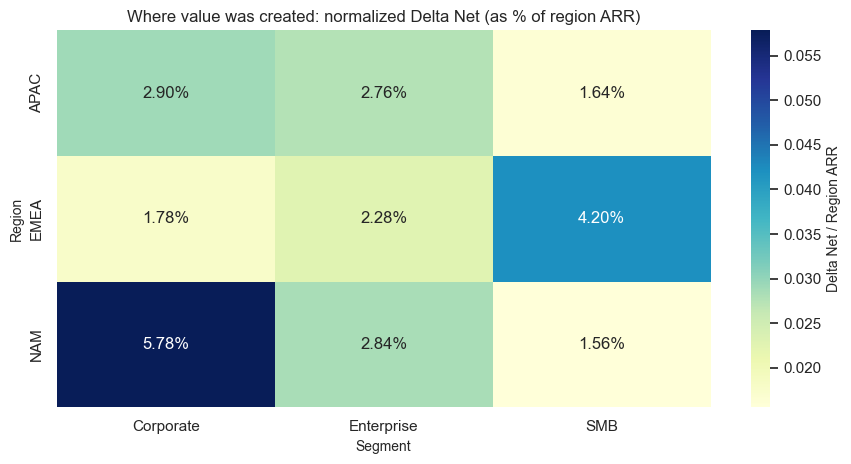

In [11]:
def build_delta_by_segment(base_kpi_df: pd.DataFrame, final_kpi_df: pd.DataFrame) -> pd.DataFrame:
    b = base_kpi_df[['region','segment','arr','net']].rename(columns={'net':'net_base'})
    f = final_kpi_df[['region','segment','net']].rename(columns={'net':'net_sim'})
    m = b.merge(f, on=['region','segment'], how='left')
    reg_arr = b.groupby('region', as_index=False)['arr'].sum().rename(columns={'arr':'arr_region'})
    m = m.merge(reg_arr, on='region', how='left')
    m['delta_net'] = m['net_sim'].fillna(0) - m['net_base'].fillna(0)
    m['delta_net_pct_region'] = np.where(m['arr_region']>0, m['delta_net']/m['arr_region'], 0.0)
    return m

def plot_heatmap_delta(df_cell_delta: pd.DataFrame, title: str):
    pivot = df_cell_delta.pivot(index='region', columns='segment', values='delta_net_pct_region')
    plt.figure(figsize=(9,4.8))
    ax = sns.heatmap(pivot, annot=True, fmt='.2%', cmap='YlGnBu', cbar_kws={'label':'Delta Net / Region ARR'})
    ax.set_title(title)
    ax.set_xlabel('Segment')
    ax.set_ylabel('Region')
    plt.tight_layout()
    plt.show()

# Build base/final cell-level metrics for plotting
base_eval  = kpi_by_region_segment.copy()
base_eval['net'] = kpi_by_region_segment['new'] + kpi_by_region_segment['reactivated'] + kpi_by_region_segment['expansion'] - kpi_by_region_segment['contraction'] - kpi_by_region_segment['churned']
final_eval = kpi_sim_after.copy()
final_eval['net'] = kpi_sim_after['new'] + kpi_sim_after['reactivated'] + kpi_sim_after['expansion'] - kpi_sim_after['contraction'] - kpi_sim_after['churned']

delta_kpi_by_segment = build_delta_by_segment(base_eval, final_eval)
plot_heatmap_delta(delta_kpi_by_segment, 'Where value was created: normalized Delta Net (as % of region ARR)')


## 10 — Executive Summary (consulting‑ready)

In [14]:
print('='*60)
print('BASELINE (global)')
print('-'*60)
print(base_global[['opening','GRR','NRR','net']].to_string(index=False))

print('' + '='*60)
print('SCENARIO COMPARISON')
print('-'*60)
print(comp_df.to_string(index=False))

print('' + '='*60)
print('GREEDY OPTIMIZATION RESULTS')
print('-'*60)
print(summary_df.to_string(index=False))

if not picks_df.empty:
    top3 = picks_df.sort_values('ROI', ascending=False).head(3).copy()
    top3['Delta Net (kEUR)'] = (top3['delta_net'] / 1000).round(1)
    top3['Effort (units)'] = top3['effort'].round(2)
    top3['ROI (EUR per unit)'] = top3['ROI'].round(0).astype(int)
    display_cols = ['region','segment','lever','Delta Net (kEUR)','Effort (units)','ROI (EUR per unit)']

    print('' + '='*60)
    print('TOP 3 GREEDY MOVES (sorted by ROI)')
    print('-'*60)
    with pd.option_context('display.max_rows', None, 'display.width', None):
        print(top3[display_cols].to_string(index=False))


BASELINE (global)
------------------------------------------------------------
  opening      GRR      NRR        net
4891680.0 0.705637 0.705637 11618568.0
SCENARIO COMPARISON
------------------------------------------------------------
       Scenario  Delta Net ARR (EUR)  Delta GRR (pct)  Delta NRR (pct)  Effort (units)
Retention-first            20882.340         0.426895         0.426895          2.3100
Balanced Growth           345634.944         0.000000         0.000000         14.5824
 Protect Whales            10955.880         0.041566         0.041566          0.6300
GREEDY OPTIMIZATION RESULTS
------------------------------------------------------------
 Budget used (units)  Delta Net ARR (EUR)  Delta GRR (pct)  Delta NRR (pct)
           49.992349         1.354803e+06         0.148349         0.148349
TOP 3 GREEDY MOVES (sorted by ROI)
------------------------------------------------------------
region    segment   lever  Delta Net (kEUR)  Effort (units)  ROI (EUR per uni

## 11 — Export (CSV/JSON) for deck & automation

In [13]:
export_dir = project_root / 'outputs' / 'decision_engine_outputs'
export_dir.mkdir(parents=True, exist_ok=True)
scenario_out = export_dir / 'scenario_compare.csv'
greedy_out   = export_dir / 'greedy_summary.json'

scenario_export = comp_df.rename(columns={
    'Scenario':      'option',
    'Delta Net ARR (EUR)': 'delta_net_eur',
    'Delta GRR (pct)':    'delta_grr_pct',
    'Delta NRR (pct)':    'delta_nrr_pct',
    'Effort (units)':   'effort_units',
})[['option','delta_net_eur','delta_grr_pct','delta_nrr_pct','effort_units']]
scenario_export.to_csv(scenario_out, index=False)

greedy_payload = {
    'budget_used_units': float(summary_df['Budget used (units)'].iat[0]) if not summary_df.empty else 0.0,
    'delta_net_eur':  float(summary_df['Delta Net ARR (EUR)'].iat[0]) if not summary_df.empty else 0.0,
    'delta_grr_pct':   float(summary_df['Delta GRR (pct)'].iat[0]) if not summary_df.empty else 0.0,
}
with greedy_out.open('w', encoding='utf-8') as f:
    json.dump(greedy_payload, f, indent=2)

print(f'✓ Exported to {export_dir.relative_to(project_root)}/')
print(f'  - {scenario_out.name}')
print(f'  - {greedy_out.name}')


✓ Exported to outputs\decision_engine_outputs/
  - scenario_compare.csv
  - greedy_summary.json
